Exercise - Investigate high paying skills

In [1]:
#Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import ast

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

#convert skill list column into a list
def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)  
    return skill_list  # Return the original NaN value

df['job_skills'] = df['job_skills'].apply(clean_list)

c:\Users\Greg\anaconda3\envs\Python_Data_Project_1_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Analysis of Data Engineer jobs in India
df_DE_In = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Engineer')].copy()

#drop the none values from the column
df_DE_In = df_DE_In.dropna(subset=['salary_year_avg'])

#analyse the different job skills
df_DE_In = df_DE_In.explode('job_skills')

# exploratory data analysis using the groupby method
df_DE_In_group = df_DE_In.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_DE_top_pay = df_DE_In_group.sort_values(by='median', ascending=False).head(10)
df_DE_skills = df_DE_In_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False).head(10)


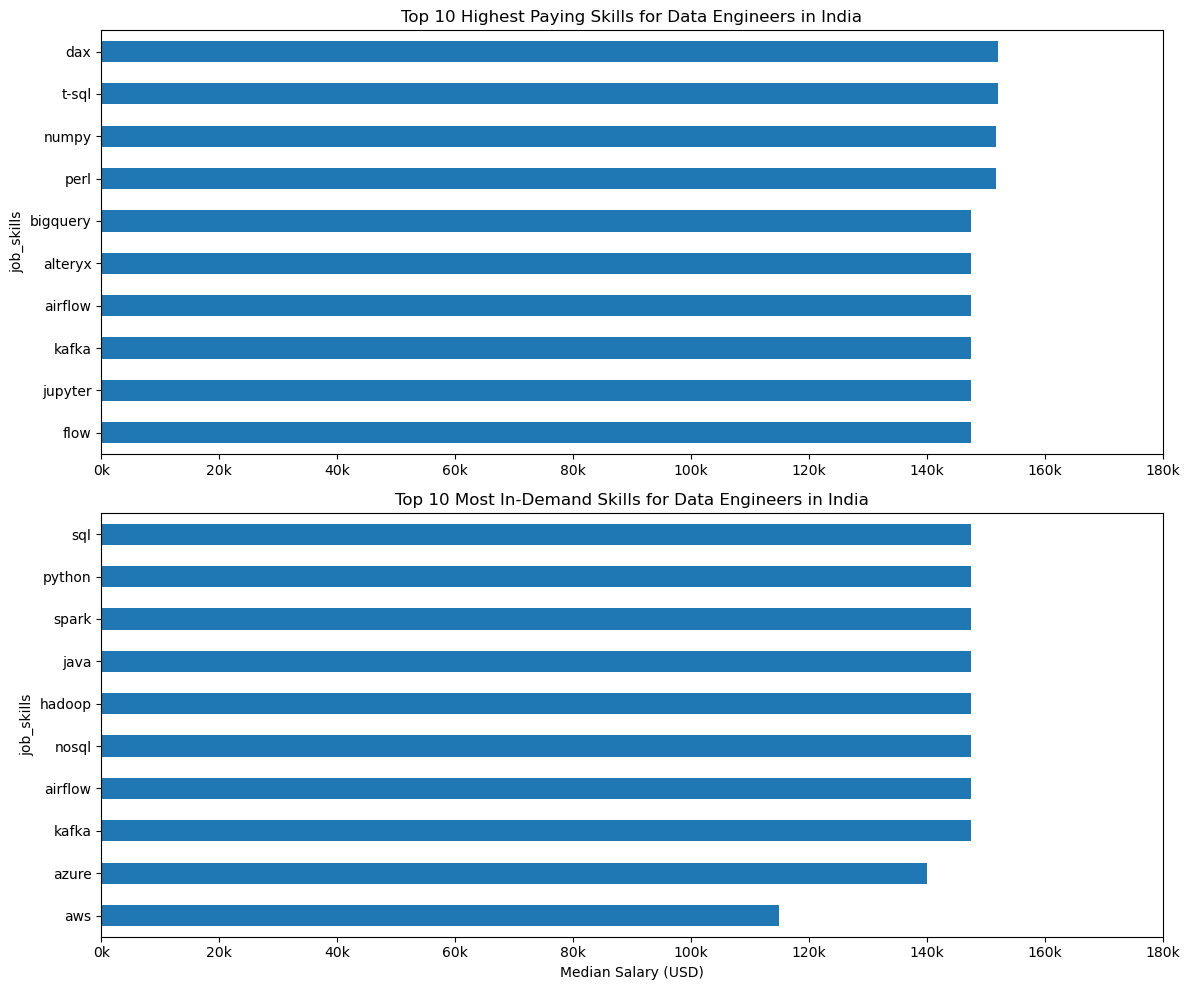

In [3]:
# Plotting the two on top of each other
import matplotlib.ticker as ticker

fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Top plot - Highest paying skills
df_DE_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paying Skills for Data Engineers in India', fontsize=12)
ax[0].set_xlabel('')
ax[0].set_xlim(0, 180000)

# Format x-axis for top plot
def format_salary(x, pos):
    return f'{x/1000:.0f}k'

ax[0].xaxis.set_major_formatter(ticker.FuncFormatter(format_salary))

# Bottom plot - Most in-demand skills
df_DE_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].invert_yaxis()
ax[1].set_title('Top 10 Most In-Demand Skills for Data Engineers in India', fontsize=12)
ax[1].set_xlabel('Median Salary (USD)', fontsize=10)

# Format x-axis for bottom plot
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(format_salary))

# Match x-axis limits
ax[1].set_xlim(ax[0].get_xlim())

plt.tight_layout()
plt.show()